In [2]:
import os
os.chdir('/media/umar/New Volume/Shareable folders/Data_TDC/data_IC50_chemberta/ML_MT/DYRK1A')
final_df= pd.read_csv("dedeuplicated_combined_ic50.csv")
##check for duplication
# Ensure SMILES column is treated as string
final_df["smiles"] = final_df["smiles"].astype(str)

# Check for duplicates in the 'smiles' column
duplicates = final_df[final_df.duplicated("smiles", keep=False)]  # keep=False shows *all* duplicates

# Print number and preview of duplicates
print(f"Total duplicate SMILES entries: {len(duplicates)}")
print(duplicates.head())


#classification actives/inactives

# 2) Convert IC50 column to numeric (in case there were strings)
final_df['standard_value'] = pd.to_numeric(final_df['standard_value'], errors='coerce')

# 3) Add classification column
final_df['label'] = (final_df['standard_value'] < 1000).astype(int)
# 1 = Active, 0 = Inactive


# 4) Quick sanity check
print(final_df[['standard_value', 'label']].head())

# 5) (Optional) Save back out
# final_df.to_csv("dedeuplicated_combined_ic50.csv", index=False)


Total duplicate SMILES entries: 0
Empty DataFrame
Columns: [smiles, standard_value, is_valid, label]
Index: []
   standard_value  label
0          2100.0      0
1          1000.0      0
2            11.0      1
3            11.0      1
4         26000.0      0


In [1]:
#to fetch ic5o with header  run the bewlow  command in terminal 
#head -n 1 ABL1_P00519_values.csv > ABL1_P00519_IC50_only.csv
#grep "IC50" ABL1_P00519_values.csv >> ABL1_P00519_IC50_only.csv


import os
# os.chdir('/media/umar/New Volume/Shareable folders/Data_TDC/data_IC50_chemberta/ML_MT/DYRK1A')

import pandas as pd
import matplotlib.pyplot as plt   # ← add this

df= pd.read_csv("dedeuplicated_combined_ic50.csv")

import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

def load_and_clean(path):
    try:
        df = pd.read_csv(path)
    except Exception as e:
        print(f"ERROR loading data: {e}")
        return None
    if not {'smiles', 'label'}.issubset(df.columns):
        print(f"ERROR: Required columns missing: {df.columns.tolist()}")
        return None
    df = df.dropna(subset=['smiles', 'label'])
    df = df[df['smiles'].str.strip().ne('')].copy()
    df['label'] = pd.to_numeric(df['label'], errors='raise').astype(int)
    print(f"Loaded {len(df)} clean entries; labels: {sorted(df['label'].unique())}")
    return df

def validate_smiles(df, sample_n=500, threshold=0.9):
    smpls = df['smiles'].sample(min(sample_n, len(df)), random_state=42)
    valid = smpls.apply(lambda s: Chem.MolFromSmiles(s) is not None).mean()
    print(f"SMILES valid on sample: {valid:.1%}")
    if valid < threshold:
        df = df[df['smiles'].apply(lambda s: Chem.MolFromSmiles(s) is not None)].copy()
        print(f"Filtered invalid SMILES; remaining: {len(df)}")
    return df

def split_and_test(df):
    y = df['label'].values
    min_cls = np.min(np.bincount(y))
    strat = y if min_cls >= 2 else None
    if strat is None:
        print("WARNING: Cannot stratify; some classes with <2 samples")
    X_train, X_test, y_train, y_test = train_test_split(
        df['smiles'].values, y, test_size=0.2, stratify=strat, random_state=42
    )
    ok = sum(AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(s), 2, 2048) is not None 
             for s in X_train[:5])
    print(f"FP test: {ok}/5 successful")
    return X_train, X_test, y_train, y_test

def gen_fps(smiles, radius=2, nbits=2048):
    fps, idx = [], []
    for i, s in enumerate(smiles):
        m = Chem.MolFromSmiles(s)
        if m:
            bit = AllChem.GetMorganFingerprintAsBitVect(m, radius, nbits)
            if bit:
                fps.append(np.array(bit))
                idx.append(i)
    return np.array(fps), idx

from collections import Counter

def apply_smote(X_fp, y, imbalance_thresh=0.5):
    class_counts = Counter(y)
    if len(class_counts) <= 1:
        print("Only one class present, skipping SMOTE")
        return X_fp, y

    majority_class = max(class_counts, key=class_counts.get)
    minority_class = min(class_counts, key=class_counts.get)
    ratio = class_counts[minority_class] / class_counts[majority_class]

    print(f"Class distribution before SMOTE: {dict(class_counts)}")
    
    if ratio < imbalance_thresh:
        print("Applying SMOTE...")
        minority_count = class_counts[minority_class]
        k_neighbors = min(5, max(1, minority_count - 1))  # ensure at least 1
        sm = SMOTE(random_state=42, k_neighbors=k_neighbors)
        return sm.fit_resample(X_fp, y)

    print("SMOTE not needed")
    return X_fp, y


def pipeline(path):
    df = load_and_clean(path)
    if df is None: return
    df = validate_smiles(df)
    X_train, X_test, y_train, y_test = split_and_test(df)
    X_tr_fp, tr_idx = gen_fps(X_train)
    if not len(X_tr_fp):
        print("ERROR: No valid fingerprints generated")
        return
    y_tr = y_train[tr_idx]
    X_train_bal, y_train_bal = apply_smote(X_tr_fp, y_tr)
    print(f"Train size: {len(y_tr)} → {len(y_train_bal)} after SMOTE")
    return {
        'df_clean': df,
        'X_train': X_train_bal, 'y_train': y_train_bal,
        'X_test': gen_fps(X_test)[0], 'y_test': y_test
    }

if __name__ == "__main__":
    print("Running pipeline...")
    res = pipeline("dedeuplicated_combined_ic50.csv")
    if res:
        print("Pipeline completed.")
        print(res['df_clean'][['smiles','label']].head())


Running pipeline...
Loaded 3232 clean entries; labels: [0, 1]
SMILES valid on sample: 100.0%
FP test: 5/5 successful
Class distribution before SMOTE: {1: 1712, 0: 873}
SMOTE not needed
Train size: 2585 → 2585 after SMOTE
Pipeline completed.
                                         smiles  label
0                  Brc1c(Br)c(Br)c2[nH]cnc2c1Br      0
1                  Brc1c(Br)c(Br)c2[nH]nnc2c1Br      0
2  Brc1cc(Br)cc(CNc2nccc(-c3ccc4c(c3)OCO4)n2)c1      1
3    Brc1cc(Br)cc(CNc2nccc(n2)-c2ccc3OCOc3c2)c1      1
4      Brc1ccc(CNc2ccnc(-c3ccc4c(c3)OCO4)n2)cn1      0


In [12]:
if res:
    # Save cleaned dataset
    res['df_clean'].to_csv("df_clean.csv", index=False)

    # Save train and test features/labels as readable CSVs
    pd.DataFrame(res['X_train']).to_csv("X_train.csv", index=False)
    pd.DataFrame(res['y_train'], columns=["label"]).to_csv("y_train.csv", index=False)
    pd.DataFrame(res['X_test']).to_csv("X_test.csv", index=False)
    pd.DataFrame(res['y_test'], columns=["label"]).to_csv("y_test.csv", index=False)


In [16]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    precision_score, recall_score,
    confusion_matrix, matthews_corrcoef
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib

# 1) PREPARE DATA — split into training and hold‑out test set
#    ensures test set is never used during parameter tuning
X_train = res['X_train']
y_train = res['y_train']
X_test = res['X_test']
y_test = res['y_test']
print(f"[DATA] {X_train.shape[0]} train samples, {X_test.shape[0]} test samples")

# 2) DEFINE MODELS AND PARAMETER GRIDS for nested CV
#    each grid will be searched with a 5‑fold inner loop
models = {
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42),
    "SVM": Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(probability=True, random_state=42))
    ]),
    "KNN": Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier())
    ]),
    "NaiveBayes": GaussianNB(),
    "XGBClassifier": XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    )
}
param_grids = {
    "CatBoost": {
        'depth': [4, 6, 8],
        'learning_rate': [0.01, 0.1],
        'iterations': [100, 300]
    },
    "SVM": {
        'svc__C': [0.1, 1, 10],
        'svc__gamma': ['scale', 'auto']
    },
    "KNN": {
        'knn__n_neighbors': [3, 5, 7],
        'knn__weights': ['uniform', 'distance']
    },
    "NaiveBayes": {
        'var_smoothing': [1e-9, 1e-8, 1e-7]
    },
    "XGBClassifier": {
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1],
        'n_estimators': [100, 300]
    }
}
print(f"[MODELS] Prepared {len(models)} estimators with parameter grids")

# 3) SET UP outer CV splitter for consistency (not used directly since we have a hold‑out test)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("[CV] Stratified 5‑fold configured for inner GridSearchCV")

def tune_and_evaluate(name, estimator, param_grid):
    """
    Performs:
    - Inner 5‑fold GridSearchCV on X_train/y_train to find best hyperparameters
    - Fits best estimator on full X_train
    - Evaluates on hold‑out X_test/y_test
    - Computes precision, recall (sensitivity), specificity, MCC
    - Saves the best model to disk
    """
    print(f"\n----- {name} Grid Search & Evaluation -----")
    
    # 3a) Inner grid search
    grid = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring='f1_macro',
        cv=outer_cv,
        n_jobs=-1,
        verbose=1
    )
    grid.fit(X_train, y_train)
    print(f"[GRID] Best params for {name}: {grid.best_params_}")
    print(f"[GRID] Best CV F1‑macro: {grid.best_score_:.3f}")
    
    # 3b) Fit best estimator on full training data
    best_model = grid.best_estimator_
    best_model.fit(X_train, y_train)
    print(f"[FIT] Trained {name} on all {X_train.shape[0]} training samples")
    
    # 3c) Predict on hold‑out test set
    y_pred = best_model.predict(X_test)
    tn, fp, fn, tp = confusion_matrix(
        y_test, y_pred, labels=[0, 1]
    ).ravel()
    
    # 3d) Compute metrics
    precision   = precision_score(y_test, y_pred)
    sensitivity = recall_score(y_test, y_pred)
    specificity = tn / (tn + fp)
    mcc         = matthews_corrcoef(y_test, y_pred)
    print(f"[TEST] Precision: {precision:.3f}")
    print(f"[TEST] Sensitivity (Recall): {sensitivity:.3f}")
    print(f"[TEST] Specificity: {specificity:.3f}")
    print(f"[TEST] MCC: {mcc:.3f}")
    
    # 3e) Save the best model
    fname = f"{name.lower()}_best_model.pkl"
    joblib.dump(best_model, fname)
    print(f"[SAVE] {name} model saved to {fname}")
    
    return {
        "Model": name,
        "Best_Params": grid.best_params_,
        "CV_F1_Macro": grid.best_score_,
        "Precision": precision,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "MCC": mcc
    }

# 4) RUN tuning & evaluation for all models
results = []
for name, model in models.items():
    grid_results = tune_and_evaluate(name, model, param_grids[name])
    results.append(grid_results)

# 5) SUMMARIZE all results
df_results = pd.DataFrame(results)
print("\n=== All Models Summary ===")
print(df_results.to_string(index=False))


[DATA] 2585 train samples, 647 test samples
[MODELS] Prepared 5 estimators with parameter grids
[CV] Stratified 5‑fold configured for inner GridSearchCV

----- CatBoost Grid Search & Evaluation -----
Fitting 5 folds for each of 12 candidates, totalling 60 fits
[GRID] Best params for CatBoost: {'depth': 8, 'iterations': 300, 'learning_rate': 0.1}
[GRID] Best CV F1‑macro: 0.910
[FIT] Trained CatBoost on all 2585 training samples
[TEST] Precision: 0.931
[TEST] Sensitivity (Recall): 0.972
[TEST] Specificity: 0.858
[TEST] MCC: 0.850
[SAVE] CatBoost model saved to catboost_best_model.pkl

----- SVM Grid Search & Evaluation -----
Fitting 5 folds for each of 6 candidates, totalling 30 fits
[GRID] Best params for SVM: {'svc__C': 10, 'svc__gamma': 'auto'}
[GRID] Best CV F1‑macro: 0.902
[FIT] Trained SVM on all 2585 training samples
[TEST] Precision: 0.941
[TEST] Sensitivity (Recall): 0.965
[TEST] Specificity: 0.881
[TEST] MCC: 0.857
[SAVE] SVM model saved to svm_best_model.pkl

----- KNN Grid Se

/home/umar/.local/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [19:13:45] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/umar/.local/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [19:13:45] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/umar/.local/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [19:13:45] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/umar/.local/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [19:13:45] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/umar/.local/lib/python3.10/site-packages/xgboost/training.py:183: 

[GRID] Best params for XGBClassifier: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300}
[GRID] Best CV F1‑macro: 0.903
[FIT] Trained XGBClassifier on all 2585 training samples
[TEST] Precision: 0.909
[TEST] Sensitivity (Recall): 0.958
[TEST] Specificity: 0.812
[TEST] MCC: 0.793
[SAVE] XGBClassifier model saved to xgbclassifier_best_model.pkl

=== All Models Summary ===
        Model                                                 Best_Params  CV_F1_Macro  Precision  Sensitivity  Specificity      MCC
     CatBoost       {'depth': 8, 'iterations': 300, 'learning_rate': 0.1}     0.909677   0.930804     0.972028     0.857798 0.849921
          SVM                        {'svc__C': 10, 'svc__gamma': 'auto'}     0.901668   0.940909     0.965035     0.880734 0.857032
          KNN         {'knn__n_neighbors': 3, 'knn__weights': 'distance'}     0.891356   0.934389     0.962704     0.866972 0.842903
   NaiveBayes                                    {'var_smoothing': 1e-07}     0.695224

In [25]:
#saving test and train dp
import numpy as np

# Assuming you already have these arrays ready
# X_train, X_test, y_train, y_test

np.savez_compressed(
    'train_test_data.npz',
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)
print("✅ Train/test data saved to train_test_data.npz")


✅ Train/test data saved to train_test_data.npz


In [18]:
# Count how many of each
counts = df['label'].value_counts().sort_index()
print("Inactives (0):", counts.get(0, 0))
print("Actives   (1):", counts.get(1, 0))
print(len(df))

Inactives (0): 1091
Actives   (1): 2141
3232


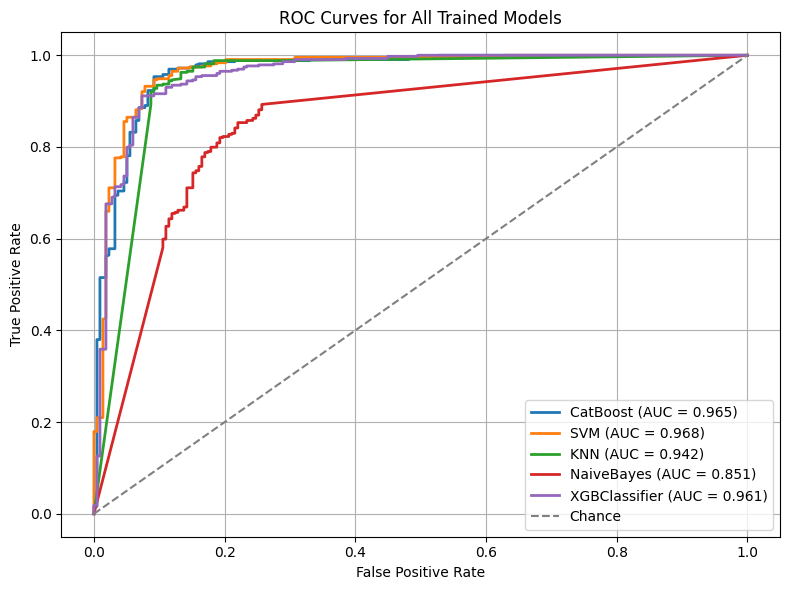

In [19]:
#ROC Generation
import joblib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split

# ── 1) LOAD OR RECONSTRUCT YOUR TEST SET ────────────────────────────────────────
# Option A: If you previously saved your test split, uncomment:
data = np.load('test_data.npz')
X_test, y_test = data['X_test'], data['y_test']

# Option B: Otherwise, rebuild it exactly as before:
# (This requires you to still have `res['X_train']`, etc. in memory)
# X_train = res['X_train']
# y_train = res['y_train']
# X_test = res['X_test']
# y_test = res['y_test']
# print(f"[DATA] {X_train.shape[0]} train samples, {X_test.shape[0]} test samples")


# ── 2) LOAD YOUR SAVED MODELS ───────────────────────────────────────────────────
model_files = {
    'CatBoost':      'catboost_best_model.pkl',
    'SVM':           'svm_best_model.pkl',
    'KNN':           'knn_best_model.pkl',
    'NaiveBayes':    'naivebayes_best_model.pkl',
    'XGBClassifier': 'xgbclassifier_best_model.pkl'
}
models = {name: joblib.load(path) for name, path in model_files.items()}

# ── 3) COMPUTE & PLOT ROC FOR EACH MODEL ───────────────────────────────────────
plt.figure(figsize=(8,6))
for name, model in models.items():
    # Get a “score” for each test sample
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(X_test)[:, 1]
    else:
        # e.g. SVM without proba
        df = model.decision_function(X_test)
        scores = (df - df.min()) / (df.max() - df.min())  # normalize to [0,1]

    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

# Random chance line
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Chance')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for All Trained Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()

plt.savefig('ROC_DYRK1A.png')
plt.show()

In [21]:
#saving best parameters
import json

# after grid.fit(...)
best_params = grid_results
for name, model in models.items():
    with open(f"{name.lower()}_best_params.json", "w") as f:
        json.dump(best_params, f, indent=2)
        print(f"[SAVE] Best hyperparameters saved to {name.lower()}_best_params.json")


[SAVE] Best hyperparameters saved to catboost_best_params.json
[SAVE] Best hyperparameters saved to svm_best_params.json
[SAVE] Best hyperparameters saved to knn_best_params.json
[SAVE] Best hyperparameters saved to naivebayes_best_params.json
[SAVE] Best hyperparameters saved to xgbclassifier_best_params.json


In [8]:
# saving test evaluation
np.savez("test_data.npz", X_test=X_test, y_test=y_test)
print("[SAVE] Test data saved to test_data.npz")

[SAVE] Test data saved to test_data.npz


In [3]:
#$### To run in terminal for conversion of pdbqt -> smiles and store in .csv
# mkdir smiles_output

# for file in *.pdbqt; do
#     obabel "$file" -O "smiles_output/${file%.pdbqt}.smi" --gen3d
# done

# # Combine into CSV
# echo "Compound,SMILES" > fda_compounds.csv
# for f in smiles_output/*.smi; do
#     name=$(basename "$f" .smi)
#     smiles=$(cat "$f")
#     echo "$name,$smiles" >> fda_compounds.csv
# done


In [22]:
npz = np.load('train_data.npz')
X_train, y_train = npz['X_train'], npz['y_train']
## for voting ensembl
from sklearn.ensemble import VotingClassifier
import joblib
import numpy as np
from sklearn.metrics import (
    precision_score, recall_score, confusion_matrix, matthews_corrcoef,
    roc_auc_score, average_precision_score
)

# — assume X_train, y_train, X_test, y_test are already prepared —

# 1) Load your tuned base models
cat = joblib.load("catboost_best_model.pkl")
xgb = joblib.load("xgbclassifier_best_model.pkl")
svm = joblib.load("svm_best_model.pkl")

# 2) Build the soft-voting ensemble
voting = VotingClassifier(
    estimators=[
        ('cat', cat),
        ('xgb', xgb),
        ('svm', svm)
    ],
    voting='soft',          # average predicted probabilities
    weights=[2, 2, 1],      # favor the two tree models
    n_jobs=-1
)

# 3) Fit on your balanced training data
voting.fit(X_train, y_train)

# 4) Predict & evaluate
y_pred  = voting.predict(X_test)
y_proba = voting.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0,1]).ravel()
print("Precision:   ", precision_score(y_test, y_pred))
print("Recall:      ", recall_score(y_test, y_pred))
print("Specificity: ", tn / (tn + fp))
print("MCC:         ", matthews_corrcoef(y_test, y_pred))
print("ROC AUC:     ", roc_auc_score(y_test, y_proba))
print("PR AUC:      ", average_precision_score(y_test, y_proba))

# 5) (Optional) Save your ensemble
joblib.dump(voting, "cat_xgb_knn_voting.pkl")


/home/umar/.local/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [19:20:40] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Precision:    0.9387755102040817
Recall:       0.965034965034965
Specificity:  0.8761467889908257
MCC:          0.8534809498259555
ROC AUC:      0.9683871174696863
PR AUC:       0.9754130417544284


['cat_xgb_knn_voting.pkl']

In [ ]:
#Library evailuation and screening
import pandas as pd
import numpy as np
import joblib
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from sklearn.ensemble import VotingClassifier  # if you need to rebuild
from tqdm import tqdm

# 1) Load your trained ensemble
model = joblib.load("cat_xgb_svm_voting.pkl")

# 2) Featurization helper
def smiles_to_fp(smiles_list, radius=2, nbits=2048):
    fps = np.zeros((len(smiles_list), nbits), dtype=np.uint8)
    for i, smi in enumerate(smiles_list):
        m = Chem.MolFromSmiles(smi)
        if m:
            bitvect = AllChem.GetMorganFingerprintAsBitVect(m, radius, nbits)
            arr = np.zeros((nbits,), dtype=int)
            DataStructs.ConvertToNumpyArray(bitvect, arr)
            fps[i, :] = arr
    return fps

# 3) Stream in chunks, predict, and write out
input_csv  = "coconut_csv-06-2025.csv"
output_csv = "library_with_predictions.csv"
chunksize  = 20_000

reader = pd.read_csv(input_csv, chunksize=chunksize)

# Write header once
first = True
for chunk in tqdm(reader, desc="Chunks"):
    # a) Featurize
    smiles = chunk["canonical_smiles"].fillna("").values
    X_chunk = smiles_to_fp(smiles)

    # b) Predict labels & scores
    y_pred  = model.predict(X_chunk)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_chunk)[:, 1]
    else:
        # fallback to decision_function → sigmoid
        dfun   = model.decision_function(X_chunk)
        y_score = 1 / (1 + np.exp(-dfun))

    # c) Append results to chunk frame
    chunk = chunk.assign(
        pred_label = y_pred,
        pred_score = y_score
    )

    # d) Write (append) to disk
    chunk.to_csv(
        output_csv,
        mode='w' if first else 'a',
        header=first,
        index=False
    )
    first = False

print(f"\n✅ Done! Predictions saved to {output_csv}")


Chunks: 0it [00:00, ?it/s][19:16:54] Explicit valence for atom # 4 N, 4, is greater than permitted
[19:16:54] Explicit valence for atom # 6 N, 4, is greater than permitted
[19:16:54] Explicit valence for atom # 6 N, 4, is greater than permitted
[19:16:54] Explicit valence for atom # 2 N, 4, is greater than permitted
[19:16:54] Explicit valence for atom # 11 N, 4, is greater than permitted
[19:16:54] Explicit valence for atom # 3 N, 4, is greater than permitted
[19:16:54] Explicit valence for atom # 9 N, 4, is greater than permitted
[19:16:54] Explicit valence for atom # 3 N, 4, is greater than permitted
[19:16:54] Explicit valence for atom # 7 N, 4, is greater than permitted
[19:16:54] Explicit valence for atom # 1 N, 4, is greater than permitted
[19:16:54] Explicit valence for atom # 1 N, 4, is greater than permitted
[19:16:54] Explicit valence for atom # 5 N, 4, is greater than permitted
[19:16:54] Explicit valence for atom # 20 C, 5, is greater than permitted
[19:16:54] Explicit val


✅ Done! Predictions saved to /media/umar/New Volume/Shareable folders/Data_TDC/data_IC50_chemberta/ML_MT/FDA_DYRK1Apredictions.csv


In [ ]:
# For active molecule sorting to othr file 

import pandas as pd

# 1) Load the file you just generated
df = pd.read_csv("/media/umar/New Volume/Shareable folders/Data_TDC/data_IC50_chemberta/ML_MT/FDA_DYRK1Apredictions.csv")

# 2) Count how many predicted 0’s vs. 1’s
counts = df["pred_label"].value_counts().sort_index()
print("Label counts:\n", counts)

# 3) (Optional) Also show percentages
percent = df["pred_label"].value_counts(normalize=True).sort_index() * 100
print("\nLabel percentages:\n", percent)

# ─────────────────────────────────────────────────────────────────────────────
# 4) Extract only the predicted actives
actives = df.loc[df["pred_label"] == 1, 
                 ["filename","smiles", "pred_score"]]

print(f"\nNumber of actives extracted: {len(actives)}")

# 5) Save them to a new CSV
actives.to_csv("/media/umar/New Volume/Shareable folders/Data_TDC/data_IC50_chemberta/ML_MT/DYRK1A_FDA_Actives.csv", index=False)
print("Saved actives to library_actives_only.csv")


Label counts:
 pred_label
0    3673
1      92
Name: count, dtype: int64

Label percentages:
 pred_label
0    97.556441
1     2.443559
Name: proportion, dtype: float64

Number of actives extracted: 92
Saved actives to library_actives_only.csv


In [4]:
import numpy as np
import joblib
from sklearn.metrics import roc_curve

# 1) load your held-out set
data = np.load('train_test_data.npz')
X_test = data['X_test']
y_test = data['y_test']

# 2) load your fitted model (e.g. your voting ensemble or any single model)
model = joblib.load('cat_xgb_knn_voting.pkl')  # or whichever .pkl you want

# 3) get the positive‐class probabilities
if hasattr(model, "predict_proba"):
    y_probs = model.predict_proba(X_test)[:, 1]
else:
    # for models without predict_proba, use decision_function + sigmoid
    df = model.decision_function(X_test)
    y_probs = 1 / (1 + np.exp(-df))

# 4) compute ROC curve and Youden’s J
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

print(f"Youden’s J optimal threshold: {best_threshold:.3f}")
print(f"Sensitivity: {tpr[best_idx]:.3f}, Specificity: {(1-fpr[best_idx]):.3f}")


Youden’s J optimal threshold: 0.673
Sensitivity: 0.942, Specificity: 0.913
